In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # !git pull
    
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
sys.path.append(str(Path.cwd().parent))
from utils._raised_cosine_basis import makeRaisedCosBasis
# from utils.load_matlab import load_mat_v73, flatten_cell
from scipy.ndimage import gaussian_filter1d
import utils
from utils import *
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

plt.rcParams['figure.dpi'] = 100 #

PyTorch: 2.10.0+cu128
CUDA available: False


## Load Data to evaluate model

In [3]:
project_root = Path.cwd().parent
# models_dir = "saved_models"
data_dir = project_root / "Data"
data = pd.read_hdf(f"{data_dir}/TemporalNoise1f_v2.h5", key='data')
print(f"Available cell types: {data['cell_type'].unique()}")
cell_type   =  "OFF transient alpha"
cell_type_slug = (
    str(cell_type).strip().lower().replace(" ", "_").replace("/", "_").replace("-", "_")
)
ctype_df = data.query(f"cell_type == '{cell_type}' and beta == 0").copy().reset_index(drop=True)

print(f"Number of cells of celltype {cell_type}: ", ctype_df["cell_name"].nunique())
print("Avialable cells:", ctype_df['cell_name'].unique())
cell_name = "061225Bc5"

cell_df =   ctype_df.query(f"cell_name == '{cell_name}'").reset_index(drop=True)
quadrant = cell_df["quadrant"][0]
spot_size = cell_df["aperture"][0]


Available cell types: <StringArray>
['OFF transient alpha', 'ON alpha', 'ON delayed', 'OFF sustained alpha']
Length: 4, dtype: str
Number of cells of celltype OFF transient alpha:  4
Avialable cells: <StringArray>
['032525Bc5', '040325Bc8', '052325Bc2', '061225Bc5']
Length: 4, dtype: str


In [5]:
dt = 1e-4
dt_stim = 1/60

In [6]:
# -------- training & test sets (once per cell) --------
stim_mat = np.stack(cell_df.loc[cell_df.noise_seed != 1, "stimulus"])
stim_rs = np.stack(cell_df.loc[cell_df.noise_seed == 1, "stimulus"])
spk_t = np.array(cell_df.loc[cell_df.noise_seed != 1, "spike_times"].tolist(), dtype=object)
spktimes_rs = np.array(cell_df.loc[cell_df.noise_seed == 1, "spike_times"].tolist(), dtype=object)

trial_dur_s = stim_mat.shape[1] * dt_stim
T_bins = int(round(trial_dur_s / dt))
bin_edges_s = np.arange(T_bins + 1) * dt

stimulus, spk_train = preprocess_split(
    stim_mat,
    spk_t,
    presamples=None,
    postsamples=None,
    n_trials=len(spk_t),
    T_cell_full=T_bins,
    dt_stim=dt_stim,
    dt=dt,
    bin_edges_s=bin_edges_s,
)
stimulus_test, spk_test = preprocess_split(
    stim_rs,
    spktimes_rs,
    presamples=None,
    postsamples=None,
    n_trials=len(spktimes_rs),
    T_cell_full=T_bins,
    dt_stim=dt_stim,
    dt=dt,
    bin_edges_s=bin_edges_s,
)

In [4]:
dt = 1e-4
# stimulus frames are at 60 Hz
# CBEM runs at 0.1 ms bins, so we upsample stimulus and re-bin spikes from spike times
dt_stim = 1 / 60.0
trial_dur_s = stim_rs.shape[1] * dt_stim

# Trim 0.5 s on each side to avoid edge effects
presamples = int(round(0.5 / dt))
postsamples = int(round(0.5 / dt))

T_cell_full = int(round(trial_dur_s / dt))
bin_edges_s = np.arange(T_cell_full + 1) * dt

stimulus_test, spk_test = preprocess_split(stim_rs, spktimes_rs, 
                                           presamples=presamples, postsamples=postsamples, 
                                           n_trials=len(spktimes_rs), 
                                        T_cell_full=T_cell_full, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)


spk_idx_test = [
    torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_test.shape[0])
]


psth_hz = spk_test.mean(axis=0) / dt   # [T] in Hz
psth_hz_smooth = gaussian_filter1d(psth_hz, sigma=int(0.02 / dt))  # 20 ms smoothing



In [5]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
B_orth.shape

(2478, 10)

In [ ]:
## LOAD trained model
models_dir = f"multi_cell/{cell_type_slug}"
ckpt_full = torch.load(f"{models_dir}/checkpoints/fuck_yeah.pt", map_location=device)

trained = CBEM_trials(binsize_s=ckpt_full["binsize_s"]).to(device)

# IMPORTANT: initialize lazy parameter before loading
# (or call trained once on dummy input with correct D)
D = ckpt_full["model_state_dict"]["B_cond"].shape[0]
trained._maybe_init_B_cond_from_D(D, device=device, dtype=torch.float32)
# t, B_orth, B_raw = makeRaisedCosBasis(10, dt, [2e-3, 150-3], 0.02, zflag=0) #should ne part of model state?

trained.load_state_dict(ckpt_full["model_state_dict"])
trained.eval()

steps_hist = ckpt_full.get("steps_hist", None)
loss_hist  = ckpt_full.get("loss_hist", None)

##Load Linear model
ckpt_linear = torch.load(f"{models_dir}/lin_model.pt", map_location=device)

cbem_lin = CBEM_linear(binsize_s=ckpt_linear["binsize_s"]).to(device)

# IMPORTANT: initialize lazy parameter before loading
# (or call trained once on dummy input with correct D)
D = ckpt_linear["model_state_dict"]["B_cond"].shape[0]
cbem_lin._maybe_init_B_cond_from_D(D, device=device, dtype=torch.float32)
# t, B_orth, B_raw = makeRaisedCosBasis(10, dt, [2e-3, 150-3], 0.02, zflag=0) #should ne part of model state?

cbem_lin.load_state_dict(ckpt_linear["model_state_dict"])
cbem_lin.eval()


CBEM_linear()

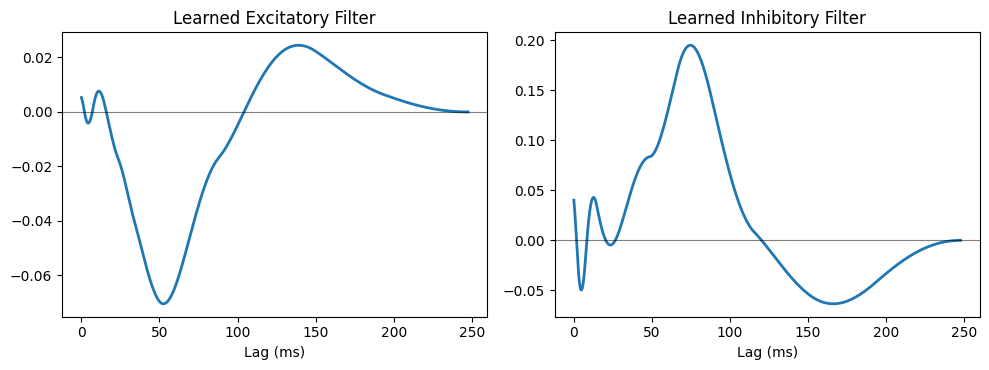

In [7]:
# Learned conductance filters in time domain
B = trained.B_cond.detach().cpu()   # [D, 2]
np.savez("B_trained", B)
W_orth = B[:-1, :]                  # drop bias row

B_orth_t = torch.as_tensor(B_orth, dtype=W_orth.dtype)
filters = B_orth_t @ W_orth            # [L, 2]

t_ms = np.arange(filters.shape[0]) * dt * 1e3

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(t_ms, filters[:, 0].numpy(), lw=2.0)
axes[0].set_title('Learned Excitatory Filter')
axes[0].set_xlabel('Lag (ms)')

axes[1].plot(t_ms, filters[:, 1].numpy(), lw=2.0)
axes[1].set_title('Learned Inhibitory Filter')
axes[1].set_xlabel('Lag (ms)')

for ax in axes:
    ax.axhline(0.0, color='k', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## Evaluate trained model

In [8]:
trained.eval()

##Design Matrix test stim
stim_test_t = torch.as_tensor(stimulus_test, dtype=torch.float32, device=device)

# stimulus_t: [B, T]
# basis_t: [L, P]
X_test_tr = [
    convolveStimulusWithBasis_torch(stim_test_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_test.shape[0])
]
X_test = torch.stack(X_test_tr, dim=0)  # [B,T,D]
print('X_full:', X_test.shape)

## LIN MODEL STATS
with torch.no_grad():
    psth_lin, aux_lin = cbem_lin(X_test)  # [B,T]
    
    
## FULL MODEL
with torch.no_grad():
    rate_test, aux = trained(X_test)  # [B,T]
B = X_test.shape[0]
T0 = 500
Y_init = torch.zeros(B, T0, device=X_test.device, dtype=X_test.dtype)  # [B,T0]
sps_t = trained.simulateSpikeTrains_trials(X_test, Y_init, seed=0).detach().cpu().numpy()
loss = cbem_penalized_nll_trials(
            model=trained,
            X_btd=X_test,
            basis_matrix=B_orth_t,
            spk_bins_list=spk_idx_test,
            window=None,
            conductance_penalty=None,)
print(loss)

X_full: torch.Size([6, 100000, 11])
tensor(504.1266, grad_fn=<AddBackward0>)


In [9]:
rate_hat = rate_test.detach().cpu()
rate_lin = psth_lin.detach().cpu()

rate_hat = gaussian_filter1d(rate_hat[0], sigma=max(1, int(0.02 / dt)))  # 20 ms
rate_lin = gaussian_filter1d(rate_lin[0], sigma=max(1, int(0.02 / dt)))  # 20 ms

In [10]:
gs = aux['gs']
Vm = aux['V']
gs.shape

torch.Size([6, 100000, 2])

# gfkgmdf

In [ ]:
cell_name = '061225Bc5'

data = np.load(f"multi_cell/off_transient_alpha/metrics/{cell_name}")
data

/tmp/ipykernel_38961/2948887753.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


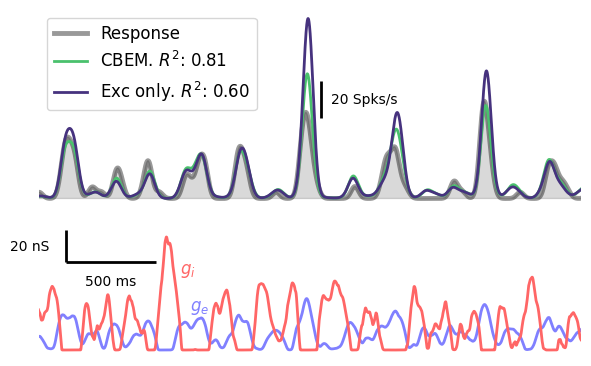

In [28]:
from sklearn.metrics import r2_score

r2_full = r2_score(psth_hz_smooth, rate_hat)
r2_lin  = r2_score(psth_hz_smooth, rate_lin)
dt_s = 1e-4
T = gs.shape[1]
t_ms = np.arange(T) * dt_s * 1e3

g = gs[0]
# if torch:
# g = gs[0].detach().cpu().numpy()

cmap = plt.get_cmap("bwr")
exc_color = cmap(0.25)
inh_color = cmap(0.8)

xmin, xmax = 5e3, 8e3
rate_bar = 20   # Hz
gbar = 20       # conductance units
time_bar = 500  # ms

fig, axes = plt.subplots(
    2, 1, figsize=(7, 4.5), sharex=True,
    gridspec_kw={"height_ratios": [1.5, 1.0], "hspace": 0.1}
)

# ---------------- Top panel: PSTH / model ----------------
axes[0].plot(t_ms, psth_hz_smooth, lw=3.5, c="k", label="Response", alpha=0.4)
axes[0].fill_between(t_ms, 0, psth_hz_smooth, color="k", alpha=0.15)
axes[0].plot(t_ms, rate_hat, lw=2.0, c=sns.color_palette("viridis")[4], label=f"CBEM. $R^2$: {r2_full:.2f}")
axes[0].plot(t_ms, rate_lin, lw=2.0, c=sns.color_palette("viridis")[0], label=f"Exc only. $R^2$: {r2_lin:.2f}")
axes[0].legend(loc='upper left', fontsize=12)
# ---------------- Bottom panel: conductances ----------------
axes[1].plot(t_ms, g[:, 0], color=exc_color, lw=2)
axes[1].plot(t_ms, g[:, 1], color=inh_color, lw=2)
# Isynax = axes[1].twinx()
# Isynax.plot(t_ms, -I_syn[0], label=['exc', 'inh'])
# Isynax.set_xlim(xmin, xmax)
# ---------------- Clean axes ----------------
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    ax.tick_params(axis="y", left=False, labelleft=False)

# ---------------- PSTH scale bar ----------------
ymin0, ymax0 = axes[0].get_ylim()
yr0 = ymax0 - ymin0

x_rate = xmax - 0.48 * (xmax - xmin)
y0_rate = ymin0 + 0.45 * yr0
y1_rate = y0_rate + rate_bar

axes[0].plot([x_rate, x_rate], [y0_rate, y1_rate], color="k", lw=2, solid_capstyle="butt")
axes[0].text(
    x_rate + 0.02 * (xmax - xmin),
    (y0_rate + y1_rate) / 2,
    f"{rate_bar} Spks/s",
    ha="left", va="center"
)

# ---------------- Conductance + time scale bars ----------------
ymin1, ymax1 = axes[1].get_ylim()
yr1 = ymax1 - ymin1

x0 = xmax - 0.95 * (xmax - xmin)
x1 = x0 + time_bar
y0 = ymin1 + 0.75 * yr1
y1 = y0 + gbar

# horizontal time bar
axes[1].plot([x0, x1], [y0, y0], color="k", lw=2, solid_capstyle="butt")
axes[1].text((x0 + x1) / 2, y0 - 0.10 * yr1, f"{time_bar} ms", ha="center", va="top")

# vertical conductance bar
axes[1].plot([x0, x0], [y0, y1], color="k", lw=2, solid_capstyle="butt")
axes[1].text(
    x0 - 0.03 * (xmax - xmin),
    (y0 + y1) / 2,
    f"{gbar} nS",
    ha="right", va="center"
)

# ---------------- Trace labels ----------------
mask = (t_ms >= xmin) & (t_ms <= xmax)

t_vis = t_ms[mask]
g_exc_vis = g[:, 0][mask]
g_inh_vis = g[:, 1][mask]

x_label_exc = xmin + 0.28 * (xmax - xmin)
x_label_inh = xmin + 0.26 * (xmax - xmin)

y_exc = np.percentile(g_exc_vis, 98)
y_inh = np.percentile(g_inh_vis, 98)

axes[1].text(
    x_label_exc, y_exc, r"$g_e$",
    color=exc_color, fontsize=12, va="center", ha="left"
)

axes[1].text(
    x_label_inh, y_inh, r"$g_i$",
    color=inh_color, fontsize=12, va="center", ha="left"
)

fig.tight_layout()
fig.savefig(fname='proof_principle', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
def compute_I_syn(gs, Vm, dt=1e-4, E_exc=0.0, E_inh=-80.0):
    """
    gs: [B, T, 2]   where gs[..., 0] = g_exc, gs[..., 1] = g_inh
    Vm: [B, T]

    Returns
    -------
    I_syn: [B, T, 2]
        I_syn[..., 0] = I_exc = g_exc * (E_exc - Vm)
        I_syn[..., 1] = I_inh = g_inh * (E_inh - Vm)
    """
    E = torch.tensor([E_exc, E_inh], dtype=gs.dtype, device=gs.device)   # [2]
    I_syn = gs * (E[None, None, :] - Vm[..., None])                      # [B,T,2]
    return I_syn

I_syn = compute_I_syn(gs, Vm)
I_syn = I_syn[0] #rn there is no trial to trial variability
I_syn.shape

torch.Size([100000, 2])

(5000.0, 8000.0)

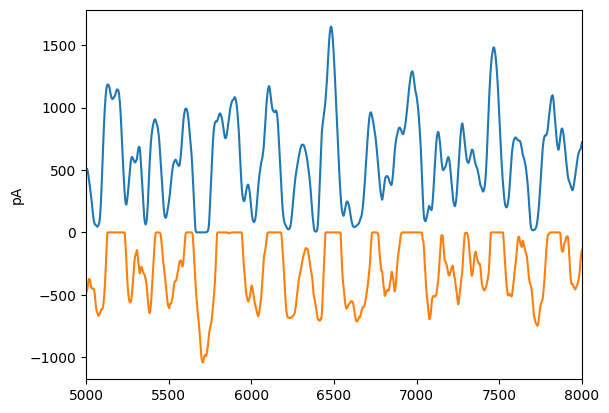

In [36]:
plt.plot(t_ms, I_syn)
plt.ylabel("pA")
plt.xlim(5e3,8e3)